## Robustez com CIFAR-100-C (Common Corruptions)

Este notebook avalia modelos treinados no CIFAR-100 no **CIFAR-100-C** (corrupções que simulam degradações comuns em imagens naturais) e reporta **accuracy por severidade (1–5)** e médias.

In [1]:
from __future__ import annotations

import os
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import tensorflow as tf

# (dica) Se der NameError por variáveis, rode esta célula primeiro.

In [3]:
# Pasta onde o CIFAR-100-C ficará cacheado
DATA_DIR = Path("datasets")
CIFAR100C_DIR = DATA_DIR / "cifar100c"
CIFAR100C_DIR.mkdir(parents=True, exist_ok=True)

# URL oficial (Hendrycks & Dietterich) via Zenodo
CIFAR100C_TAR_URL = "https://zenodo.org/record/3555552/files/CIFAR-100-C.tar?download=1"
CIFAR100C_TAR_PATH = CIFAR100C_DIR / "CIFAR-100-C.tar"


def download_file(url: str, out_path: Path, chunk_size: int = 1024 * 1024) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"OK (já existe): {out_path} ({out_path.stat().st_size/1e6:.1f} MB)")
        return

    print("Baixando (pode demorar; arquivo grande):", url)
    tmp_path = out_path.with_suffix(out_path.suffix + ".part")
    if tmp_path.exists():
        tmp_path.unlink()

    with urllib.request.urlopen(url) as r, open(tmp_path, "wb") as f:
        total_hdr = r.headers.get("Content-Length")
        total = int(total_hdr) if total_hdr and total_hdr.isdigit() else None

        downloaded = 0
        next_report = 0
        report_step = 50 * 1024 * 1024  # 50 MB

        while True:
            chunk = r.read(chunk_size)
            if not chunk:
                break
            f.write(chunk)
            downloaded += len(chunk)

            if downloaded >= next_report:
                next_report = downloaded + report_step
                if total:
                    pct = 100.0 * downloaded / total
                    print(f"  {pct:6.2f}% ({downloaded/1e6:.1f}/{total/1e6:.1f} MB)")
                else:
                    print(f"  {downloaded/1e6:.1f} MB")

    tmp_path.replace(out_path)
    print("Download concluído:", out_path)


def extract_tar(tar_path: Path, out_dir: Path) -> None:
    # O tar contém uma pasta chamada CIFAR-100-C/ com os .npy.
    marker = out_dir / "CIFAR-100-C" / "labels.npy"
    if marker.exists():
        print("OK (já extraído):", marker)
        return

    print("Extraindo:", tar_path)
    with tarfile.open(tar_path, "r") as tar:
        # Python 3.12+ recomenda usar um filtro para extração mais segura.
        try:
            tar.extractall(path=out_dir, filter="data")
        except TypeError:
            # Compatibilidade com versões antigas do Python.
            tar.extractall(path=out_dir)

    print("Extração concluída em:", out_dir)


download_file(CIFAR100C_TAR_URL, CIFAR100C_TAR_PATH)
extract_tar(CIFAR100C_TAR_PATH, CIFAR100C_DIR)

Baixando (pode demorar; arquivo grande): https://zenodo.org/record/3555552/files/CIFAR-100-C.tar?download=1
    0.04% (1.0/2918.5 MB)
    1.83% (53.5/2918.5 MB)
    3.63% (105.9/2918.5 MB)
    5.43% (158.3/2918.5 MB)
    7.22% (210.8/2918.5 MB)
    9.02% (263.2/2918.5 MB)
   10.81% (315.6/2918.5 MB)
   12.61% (368.1/2918.5 MB)
   14.41% (420.5/2918.5 MB)
   16.20% (472.9/2918.5 MB)
   18.00% (525.3/2918.5 MB)
   19.80% (577.8/2918.5 MB)
   21.59% (630.2/2918.5 MB)
   23.39% (682.6/2918.5 MB)
   25.19% (735.1/2918.5 MB)
   26.98% (787.5/2918.5 MB)
   28.78% (839.9/2918.5 MB)
   30.58% (892.3/2918.5 MB)
   32.37% (944.8/2918.5 MB)
   34.17% (997.2/2918.5 MB)
   35.96% (1049.6/2918.5 MB)
   37.76% (1102.1/2918.5 MB)
   39.56% (1154.5/2918.5 MB)
   41.35% (1206.9/2918.5 MB)
   43.15% (1259.3/2918.5 MB)
   44.95% (1311.8/2918.5 MB)
   46.74% (1364.2/2918.5 MB)
   48.54% (1416.6/2918.5 MB)
   50.34% (1469.1/2918.5 MB)
   52.13% (1521.5/2918.5 MB)
   53.93% (1573.9/2918.5 MB)
   55.73% (1626.

In [4]:
# Localiza a raiz do CIFAR-100-C (onde ficam labels.npy e os arquivos *.npy de corrupção)

# Define o diretório base mesmo se você já tiver instalado (evita NameError fora de ordem)
DATA_DIR = Path("datasets")
CIFAR100C_DIR = DATA_DIR / "cifar100c"

def find_cifar100c_root(base_dir: Path) -> Path:
    # Procura labels.npy recursivamente e usa o diretório pai.
    hits = list(base_dir.rglob("labels.npy"))
    if not hits:
        raise FileNotFoundError(f"Não achei labels.npy em {base_dir.resolve()}")
    return hits[0].parent


CIFAR100C_ROOT = find_cifar100c_root(CIFAR100C_DIR)
print("CIFAR-100-C root:", CIFAR100C_ROOT.resolve())

labels_path = CIFAR100C_ROOT / "labels.npy"
y_c = np.load(labels_path).astype("int64")
print("labels:", y_c.shape, y_c.dtype, "classes:", np.unique(y_c).size)

# Arquivos de corrupção disponíveis (cada um com shape (50000, 32, 32, 3))
corruption_files = sorted([p for p in CIFAR100C_ROOT.glob("*.npy") if p.name != "labels.npy"])
corruptions = [p.stem for p in corruption_files]
print("num corruptions:", len(corruptions))
print("primeiras 10:", corruptions[:10])

# Convenção do CIFAR-100-C: 5 severidades, 10k imagens cada
SEVERITIES = [1, 2, 3, 4, 5]
N_PER_SEVERITY = 10_000

CIFAR-100-C root: C:\Users\saulo\PIBIC\Lightweight Analyses\datasets\cifar100c\CIFAR-100-C
labels: (50000,) int64 classes: 100
num corruptions: 19
primeiras 10: ['brightness', 'contrast', 'defocus_blur', 'elastic_transform', 'fog', 'frost', 'gaussian_blur', 'gaussian_noise', 'glass_blur', 'impulse_noise']


In [5]:
# Carrega modelos Keras (.keras) treinados no CIFAR-100
# Vamos usar como baseline o modelo com PIOR acurácia no CIFAR-100 limpo.

MODELS = [
    ("MobileNetV3Small", Path("keras_models/MobileNetV3Small_CIFAR100.keras")),
    ("EfficientNetB0", Path("keras_models/EfficientNetB0_CIFAR100.keras")),
    ("MCUNet", Path("keras_models/MCUNet_CIFAR100.keras")),
    ("MCUNet_512KB_2MB", Path("keras_models/MCUNet_CIFAR100-512kb-2mb.keras"))
]

# Você pode comentar/remover modelos que não existam.


def load_models(specs):
    out = []
    for name, path in specs:
        if not path.exists():
            print(f"AVISO: {path} não encontrado, pulando...")
            continue
        m = tf.keras.models.load_model(path)
        m.trainable = False
        out.append((name, path, m))
        print("OK:", name, "<-", path)
    return out


models = load_models(MODELS)

if not models:
    raise RuntimeError("Nenhum modelo encontrado! Verifique os caminhos.")

# Inferimos IMG_SIZE do 1º modelo (assumimos que todos usam o mesmo input size)
IMG_SIZE = int(models[0][2].input_shape[1])
BATCH_SIZE = 128
NUM_CLASSES = 100

print("IMG_SIZE:", IMG_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)

# Nomes das classes do CIFAR-100 (fine labels)
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

OK: MobileNetV3Small <- keras_models\MobileNetV3Small_CIFAR100.keras
OK: EfficientNetB0 <- keras_models\EfficientNetB0_CIFAR100.keras
OK: MCUNet <- keras_models\MCUNet_CIFAR100.keras
OK: MCUNet_512KB_2MB <- keras_models\MCUNet_CIFAR100-512kb-2mb.keras
IMG_SIZE: 160
NUM_CLASSES: 100


In [6]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image_for_model(image, label):
    # CIFAR-100-C vem em uint8 [0,255]
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method="bilinear")
    return image, label


def make_ds(x: np.ndarray, y: np.ndarray, batch_size: int = BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess_image_for_model, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def accuracy_on_ds(model: tf.keras.Model, ds: tf.data.Dataset) -> float:
    correct = 0
    total = 0
    for xb, yb in ds:
        logits = model(xb, training=False)
        pred = tf.argmax(logits, axis=-1, output_type=yb.dtype)
        correct += int(tf.reduce_sum(tf.cast(pred == yb, tf.int32)).numpy())
        total += int(yb.shape[0])
    return correct / max(total, 1)

In [7]:
def load_corruption(corruption: str) -> np.ndarray:
    path = CIFAR100C_ROOT / f"{corruption}.npy"
    if not path.exists():
        raise FileNotFoundError(f"Não achei {path}")
    x = np.load(path)  # (50000, 32, 32, 3)
    if x.ndim != 4 or x.shape[1:4] != (32, 32, 3):
        raise ValueError(f"Shape inesperado em {path.name}: {x.shape}")
    return x


def eval_corruption_acc(model: tf.keras.Model, corruption: str, severities=None) -> dict:
    """Retorna accuracies por severidade e média 1–5."""
    if severities is None:
        severities = globals().get("SEVERITIES", [1, 2, 3, 4, 5])
    n_per = int(globals().get("N_PER_SEVERITY", 10_000))

    x = load_corruption(corruption)
    out = {"corruption": corruption}

    for s in severities:
        start = (s - 1) * n_per
        end = s * n_per
        x_s = x[start:end]
        y_s = y_c[start:end]

        ds = make_ds(x_s, y_s)
        out[f"acc_s{s}"] = accuracy_on_ds(model, ds)

    out["acc_mean_1_5"] = float(np.mean([out[f"acc_s{s}"] for s in severities]))
    return out


def err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)


# Avalia no CIFAR-100 limpo para TODOS os modelos e escolhe baseline = pior clean acc
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

y_test = y_test.squeeze().astype("int64")
clean_ds = make_ds(x_test, y_test)

clean = []
for name, path, m in models:
    acc = accuracy_on_ds(m, clean_ds)
    clean.append({"name": name, "path": str(path), "clean_acc": float(acc), "clean_err": err_from_acc(acc)})
    print(f"{name:16s} clean_acc={acc:.4f} clean_err={err_from_acc(acc):.4f}")

baseline = max(clean, key=lambda d: d["clean_err"])  # pior no clean
BASELINE_NAME = baseline["name"]
print("\nBaseline (pior no clean):", BASELINE_NAME, "| clean_acc=%.4f" % baseline["clean_acc"])

MobileNetV3Small clean_acc=0.7301 clean_err=0.2699
EfficientNetB0   clean_acc=0.7832 clean_err=0.2168
MCUNet           clean_acc=0.4944 clean_err=0.5056
MCUNet_512KB_2MB clean_acc=0.6169 clean_err=0.3831

Baseline (pior no clean): MCUNet | clean_acc=0.4944


In [8]:
# Avaliação por CE (Corruption Error) com persistência em JSON/JSONL
# CE(model, corr, s) = err_model(corr, s) / err_baseline(corr, s)
# Baseline = modelo com pior accuracy no clean (calculado na célula anterior).

import json
import os
from pathlib import Path

# -------------------------
# Configuração
# -------------------------
# Escolha quais corrupções avaliar (use EVAL_ALL_CORRUPTIONS=True para avaliar todas)
SELECTED = [
    "gaussian_noise",
    "shot_noise",
    "motion_blur",
    "defocus_blur",
    "brightness",
    "fog",
    "contrast",
    "jpeg_compression",
]
EVAL_ALL_CORRUPTIONS = True
if EVAL_ALL_CORRUPTIONS:
    SELECTED = corruptions

# Persistência (salva a cada item; ideal pra evitar perda em reboot)
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = f"cifar100c_baseline-{BASELINE_NAME}".replace(" ", "_")
BASELINE_ACC_PATH = RESULTS_DIR / f"{RUN_TAG}_baseline_acc.json"
CE_RESULTS_JSONL_PATH = RESULTS_DIR / f"{RUN_TAG}_ce_results.jsonl"
FORCE_RECOMPUTE = False
FSYNC_EACH_WRITE = True


def _load_json(path: Path, default):
    if not path.exists():
        return default
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return default


def _atomic_write_json(path: Path, obj) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    os.replace(tmp, path)


def _load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            # ignora linhas corrompidas/incompletas
            pass
    return rows


def _append_jsonl(path: Path, row: dict) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
        f.flush()
        if FSYNC_EACH_WRITE:
            os.fsync(f.fileno())


# -------------------------
# Baseline (com cache)
# -------------------------
baseline_model = None
for name, path, m in models:
    if name == BASELINE_NAME:
        baseline_model = m
        break
if baseline_model is None:
    raise RuntimeError(f"Não achei baseline model: {BASELINE_NAME}")

# Carrega baseline_acc salvo (se existir) e só calcula o que faltar
baseline_acc = _load_json(BASELINE_ACC_PATH, {})

for c in SELECTED:
    if (not FORCE_RECOMPUTE) and (c in baseline_acc):
        # mostra o que já tinha salvo
        try:
            print(f"[baseline/cached] {c:20s} mean_acc={baseline_acc[c]['acc_mean_1_5']:.4f}")
        except Exception:
            print(f"[baseline/cached] {c:20s} (sem acc_mean_1_5)")
        continue

    baseline_acc[c] = eval_corruption_acc(baseline_model, c)
    _atomic_write_json(BASELINE_ACC_PATH, baseline_acc)
    print(f"[baseline] {c:20s} mean_acc={baseline_acc[c]['acc_mean_1_5']:.4f}")


def ce_from_acc(acc_model: float, acc_base: float) -> float:
    eb = err_from_acc(acc_base)
    if eb <= 0:
        return float("nan")
    return err_from_acc(acc_model) / eb


# -------------------------
# CE por modelo/corrupção (resume via JSONL)
# -------------------------
ce_results = _load_jsonl(CE_RESULTS_JSONL_PATH)
latest_by_key = {}
for r in ce_results:
    if isinstance(r, dict) and "model" in r and "corruption" in r:
        latest_by_key[(r["model"], r["corruption"])] = r

done = set(latest_by_key.keys())

for name, path, m in models:
    for c in SELECTED:
        key = (name, c)
        if (not FORCE_RECOMPUTE) and (key in done):
            continue

        acc = eval_corruption_acc(m, c)
        base = baseline_acc[c]

        row = {"model": name, "corruption": c}

        # CE_s = err_model(s) / err_baseline(s)
        # Agregado (Hendrycks & Dietterich): CE = (Σ_s err_model(s)) / (Σ_s err_baseline(s))
        num_err = 0.0
        den_err = 0.0

        for s in SEVERITIES:
            acc_ms = float(acc[f"acc_s{s}"])
            acc_bs = float(base[f"acc_s{s}"])

            row[f"acc_s{s}"] = acc_ms
            row[f"ce_s{s}"] = ce_from_acc(acc_ms, acc_bs)

            num_err += err_from_acc(acc_ms)
            den_err += err_from_acc(acc_bs)

        row["acc_mean_1_5"] = float(acc["acc_mean_1_5"])

        # Mantém a métrica antiga (média das razões) só para referência/debug
        row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES]))

        # Métrica principal (bate com a fórmula do paper): razão das somas
        row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

        latest_by_key[key] = row
        done.add(key)
        _append_jsonl(CE_RESULTS_JSONL_PATH, row)

ce_results = list(latest_by_key.values())

# Resumo por modelo (mCE)
# CE(c) = (Σ_s err_model(c,s)) / (Σ_s err_baseline(c,s))
# mCE = média do CE(c) sobre corrupções
print("\n=== mCE por modelo (CE=Σ_s err/Σ_s err_baseline; média sobre corrupções) ===")
for name, _, _ in models:
    rows = [r for r in ce_results if r["model"] == name and r["corruption"] in SELECTED]
    mce = float(np.nanmean([r["ce_mean_1_5"] for r in rows]))
    print(f"{name:16s} mCE={mce:.4f}" + (" (baseline)" if name == BASELINE_NAME else ""))

# Detalhe: pior -> melhor por CE (quanto MENOR melhor; baseline tende a ~1.0)
print("\n=== Pior->melhor por corrupção (CE=Σerr/Σerr_baseline) ===")
for c in SELECTED:
    rows = [r for r in ce_results if r["corruption"] == c]
    rows = sorted(rows, key=lambda d: d["ce_mean_1_5"], reverse=True)
    top = " | ".join([f"{r['model']}={r['ce_mean_1_5']:.3f}" for r in rows])
    print(f"{c:20s} {top}")

[baseline] brightness           mean_acc=0.4486
[baseline] contrast             mean_acc=0.2439
[baseline] defocus_blur         mean_acc=0.4107
[baseline] elastic_transform    mean_acc=0.3979
[baseline] fog                  mean_acc=0.3199
[baseline] frost                mean_acc=0.3569
[baseline] gaussian_blur        mean_acc=0.3798
[baseline] gaussian_noise       mean_acc=0.2605
[baseline] glass_blur           mean_acc=0.3310
[baseline] impulse_noise        mean_acc=0.2416
[baseline] jpeg_compression     mean_acc=0.4443
[baseline] motion_blur          mean_acc=0.3716
[baseline] pixelate             mean_acc=0.4495
[baseline] saturate             mean_acc=0.3824
[baseline] shot_noise           mean_acc=0.3065
[baseline] snow                 mean_acc=0.3900
[baseline] spatter              mean_acc=0.4102
[baseline] speckle_noise        mean_acc=0.3067
[baseline] zoom_blur            mean_acc=0.3807

=== mCE por modelo (CE=Σ_s err/Σ_s err_baseline; média sobre corrupções) ===
MobileNetV

## MCUNet Oficial — Avaliação de robustez no CIFAR-100-C

Célula **autônoma**: só precisa que o CIFAR-100-C esteja baixado (células 1–4) e que o modelo `MCUNet_Official_CIFAR100.keras` exista.
Os resultados dos outros modelos **não são recalculados** — são lidos do JSONL existente.
Os novos resultados são **acrescentados** ao mesmo JSONL para que as células de visualização já existentes incluam o MCUNet Oficial.

In [1]:
# =====================================================================
# MCUNet Oficial — avaliação de robustez no CIFAR-100-C
# (célula autônoma: só precisa que o CIFAR-100-C esteja baixado)
# =====================================================================
import json, os, sys
import numpy as np
import tensorflow as tf
from pathlib import Path

# --- Registrar ImageNetNormalization (necessário para carregar o .keras) ---
_register = getattr(tf.keras.utils, 'register_keras_serializable', None) or \
            getattr(tf.keras.saving, 'register_keras_serializable', None)

@_register(package="MCUNet")
class ImageNetNormalization(tf.keras.layers.Layer):
    """Normalização ImageNet: (x/255 - mean) / std"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
    def call(self, x):
        return (x / 255.0 - self.mean) / self.std
    def get_config(self):
        return super().get_config()

# --- Configurações ---
MODEL_NAME_OFF = "MCUNet_Official"
MODEL_PATH_OFF = Path("keras_models/MCUNet_Official_CIFAR100.keras")

# Paths do CIFAR-100-C (reutiliza se já definidos no kernel)
if "CIFAR100C_ROOT" not in dir():
    CIFAR100C_ROOT = Path("datasets/cifar100c/CIFAR-100-C")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Usa os mesmos arquivos de resultados do notebook (baseline = MCUNet)
BASELINE_ACC_PATH_OFF = RESULTS_DIR / "cifar100c_baseline-MCUNet_baseline_acc.json"
CE_JSONL_PATH_OFF = RESULTS_DIR / "cifar100c_baseline-MCUNet_ce_results.jsonl"

SEVERITIES_OFF = [1, 2, 3, 4, 5]
N_PER_SEV = 10_000
BATCH_SIZE_OFF = 128
AUTOTUNE_OFF = tf.data.AUTOTUNE

# --- Carregar modelo ---
print(f"Carregando {MODEL_NAME_OFF} de {MODEL_PATH_OFF} ...")
model_off = tf.keras.models.load_model(MODEL_PATH_OFF)
model_off.trainable = False
IMG_SIZE_OFF = int(model_off.input_shape[1])
print(f"OK — IMG_SIZE={IMG_SIZE_OFF}")

# --- Funções auxiliares ---
def _preprocess_off(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE_OFF, IMG_SIZE_OFF), method="bilinear")
    return image, label

def _make_ds_off(x, y):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(_preprocess_off, num_parallel_calls=AUTOTUNE_OFF)
    ds = ds.batch(BATCH_SIZE_OFF).prefetch(AUTOTUNE_OFF)
    return ds

def _acc_off(mdl, ds):
    correct = total = 0
    for xb, yb in ds:
        pred = tf.argmax(mdl(xb, training=False), axis=-1, output_type=yb.dtype)
        correct += int(tf.reduce_sum(tf.cast(pred == yb, tf.int32)).numpy())
        total += int(yb.shape[0])
    return correct / max(total, 1)

def _err(acc):
    return 1.0 - float(acc)

# --- Labels e corrupções ---
if "y_c" not in dir():
    y_c = np.load(CIFAR100C_ROOT / "labels.npy").astype("int64")

corruptions_off = sorted([p.stem for p in CIFAR100C_ROOT.glob("*.npy") if p.name != "labels.npy"])
print(f"Corrupções: {len(corruptions_off)}")

# --- Carregar baseline (já salvo) ---
if not BASELINE_ACC_PATH_OFF.exists():
    raise FileNotFoundError(f"Baseline não encontrado: {BASELINE_ACC_PATH_OFF}\nRode a avaliação completa primeiro.")

baseline_acc_off = json.loads(BASELINE_ACC_PATH_OFF.read_text(encoding="utf-8"))
print(f"Baseline: {len(baseline_acc_off)} corrupções carregadas de {BASELINE_ACC_PATH_OFF.name}")

# --- Carregar resultados existentes (para skip) ---
def _load_jsonl_off(path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

existing_off = _load_jsonl_off(CE_JSONL_PATH_OFF)
done_off = {(r["model"], r["corruption"]) for r in existing_off if "model" in r and "corruption" in r}

# --- Clean accuracy ---
(_, _), (x_test_c100, y_test_c100) = tf.keras.datasets.cifar100.load_data()
y_test_c100 = y_test_c100.squeeze().astype("int64")
clean_acc_off = _acc_off(model_off, _make_ds_off(x_test_c100, y_test_c100))
print(f"\n{MODEL_NAME_OFF} clean_acc = {clean_acc_off:.4f}")

# --- Avaliar corrupções ---
print(f"\nAvaliando {MODEL_NAME_OFF} em {len(corruptions_off)} corrupções...")
computed_off = 0

for c in corruptions_off:
    key = (MODEL_NAME_OFF, c)
    if key in done_off:
        print(f"  [cached] {c}")
        continue

    x = np.load(CIFAR100C_ROOT / f"{c}.npy")
    base = baseline_acc_off[c]
    row = {"model": MODEL_NAME_OFF, "corruption": c}
    num_err = den_err = 0.0

    for s in SEVERITIES_OFF:
        start, end = (s - 1) * N_PER_SEV, s * N_PER_SEV
        acc_s = _acc_off(model_off, _make_ds_off(x[start:end], y_c[start:end]))
        acc_b = float(base[f"acc_s{s}"])

        row[f"acc_s{s}"] = acc_s
        row[f"ce_s{s}"] = _err(acc_s) / _err(acc_b) if _err(acc_b) > 0 else float("nan")
        num_err += _err(acc_s)
        den_err += _err(acc_b)

    row["acc_mean_1_5"] = float(np.mean([row[f"acc_s{s}"] for s in SEVERITIES_OFF]))
    row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES_OFF]))
    row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

    # Persiste no JSONL
    with CE_JSONL_PATH_OFF.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
        f.flush()
        os.fsync(f.fileno())

    done_off.add(key)
    computed_off += 1
    print(f"  [{computed_off:2d}] {c:20s} acc={row['acc_mean_1_5']:.4f}  CE={row['ce_mean_1_5']:.4f}")

# --- Resumo mCE ---
all_off = _load_jsonl_off(CE_JSONL_PATH_OFF)
latest_off = {}
for r in all_off:
    latest_off[(r["model"], r["corruption"])] = r

mcunet_off_rows = [v for (m, c), v in latest_off.items() if m == MODEL_NAME_OFF]
mce_off = float(np.nanmean([r["ce_mean_1_5"] for r in mcunet_off_rows])) * 100

print(f"\n{'=' * 60}")
print(f"MCUNet Oficial — CIFAR-100-C")
print(f"  Clean Accuracy:  {clean_acc_off:.4f}")
print(f"  mCE:             {mce_off:.2f}%")
print(f"  Corrupções:      {len(mcunet_off_rows)}")
print(f"  Resultados em:   {CE_JSONL_PATH_OFF}")
print(f"{'=' * 60}")
print("\nDica: re-rode as células de visualização abaixo para incluir MCUNet Oficial nos gráficos.")

Carregando MCUNet_Official de keras_models\MCUNet_Official_CIFAR100.keras ...

OK — IMG_SIZE=160
Corrupções: 19
Baseline: 19 corrupções carregadas de cifar100c_baseline-MCUNet_baseline_acc.json

MCUNet_Official clean_acc = 0.5868

Avaliando MCUNet_Official em 19 corrupções...
  [ 1] brightness           acc=0.4567  CE=0.9852
  [ 2] contrast             acc=0.4149  CE=0.7737
  [ 3] defocus_blur         acc=0.4929  CE=0.8605
  [ 4] elastic_transform    acc=0.4368  CE=0.9355
  [ 5] fog                  acc=0.4594  CE=0.7949
  [ 6] frost                acc=0.3090  CE=1.0745
  [ 7] gaussian_blur        acc=0.4586  CE=0.8729
  [ 8] gaussian_noise       acc=0.2173  CE=1.0584
  [ 9] glass_blur           acc=0.2255  CE=1.1577
  [10] impulse_noise        acc=0.2405  CE=1.0015
  [11] jpeg_compression     acc=0.4231  CE=1.0381
  [12] motion_blur          acc=0.4177  CE=0.9267
  [13] pixelate             acc=0.3852  CE=1.1167
  [14] saturate             acc=0.4367  CE=0.9121
  [15] shot_noise      


=== CE (%) por corrupção ===
corruption            MobileNetV3Small    EfficientNetB0            MCUNet  MCUNet_512KB_2MB
brightness                       54.32             43.55            100.00             75.44
contrast                         62.91             56.18            100.00             80.85
defocus_blur                     59.57             51.84            100.00             82.83
elastic_transform                70.86             65.41            100.00             84.71
fog                              67.75             54.91            100.00             75.64
frost                            63.51             59.06            100.00             87.27
gaussian_blur                    61.29             54.22            100.00             86.20
gaussian_noise                   91.56             80.97            100.00            103.81
glass_blur                      103.56            114.48            100.00            106.77
impulse_noise                   100.86  

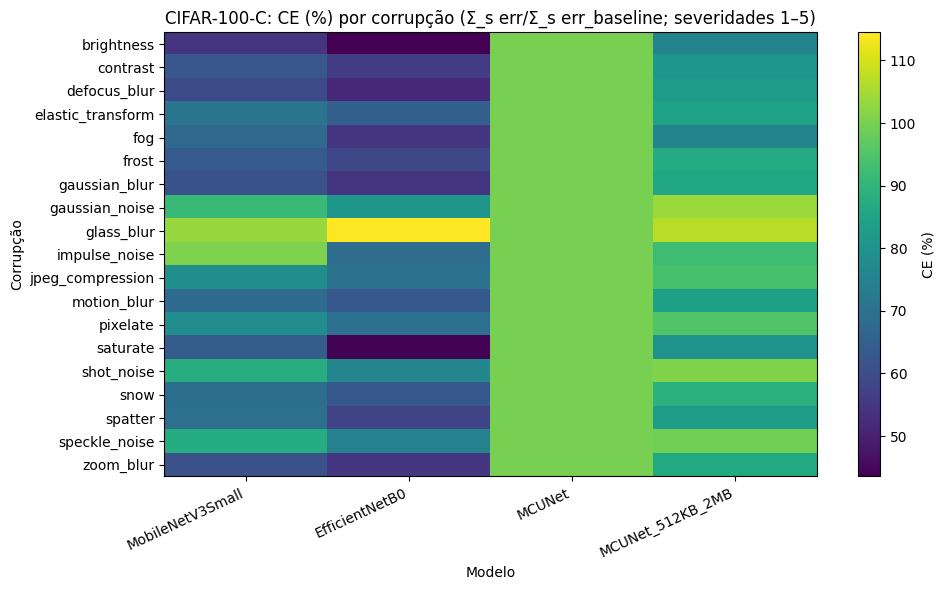

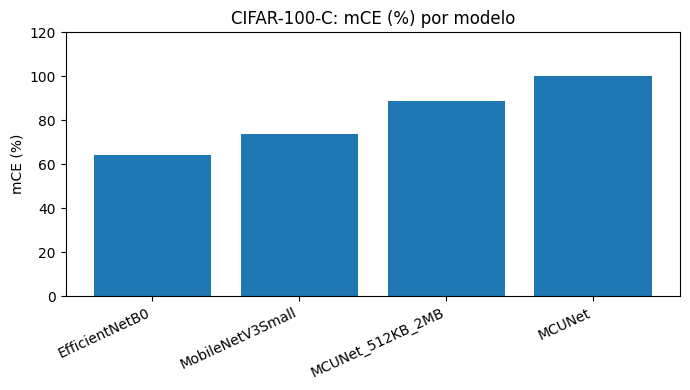

In [9]:
# Tabela + gráficos: CE e mCE em porcentagem (%)
# - CE%: por corrupção (CE=Σ_s err/Σ_s err_baseline, severidades 1–5)
# - mCE%: média do CE% sobre corrupções
#
# Importante: esta célula lê os resultados direto do JSONL em `results/`.
try:
    import json
    from pathlib import Path

    import matplotlib.pyplot as plt

    RESULTS_DIR = Path("results")

    # Prioridade: usar o caminho já definido pela célula de avaliação (se existir)
    if "CE_RESULTS_JSONL_PATH" in globals():
        JSONL_PATH = Path(CE_RESULTS_JSONL_PATH)
    else:
        # fallback: pega o primeiro *_ce_results.jsonl em results/
        matches = sorted(RESULTS_DIR.glob("cifar100c*_ce_results.jsonl"))
        if not matches:
            raise FileNotFoundError("Não achei nenhum arquivo 'cifar100c*_ce_results.jsonl' em results/.")
        JSONL_PATH = matches[0]

    def _load_latest_jsonl(path: Path):
        latest = {}
        for line in path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            if isinstance(r, dict) and "model" in r and "corruption" in r:
                latest[(r["model"], r["corruption"])] = r
        return list(latest.values())

    ce_results = _load_latest_jsonl(JSONL_PATH)

    # Preferir a ordem de `models` se estiver disponível; senão inferir do JSONL
    if "models" in globals():
        model_names = [name for name, _, _ in models]
    else:
        model_names = sorted({r.get("model") for r in ce_results if r.get("model") is not None})

    # Preferir SELECTED (se existir); senão inferir do JSONL
    if "SELECTED" in globals():
        corruptions_list = list(SELECTED)
    else:
        corruptions_list = sorted({r["corruption"] for r in ce_results if "corruption" in r})

    # CE% (corrupção x modelo)
    ce_pct = np.full((len(corruptions_list), len(model_names)), np.nan, dtype=float)
    for i, c in enumerate(corruptions_list):
        for j, name in enumerate(model_names):
            vals = [
                r["ce_mean_1_5"]
                for r in ce_results
                if r.get("model") == name and r.get("corruption") == c
            ]
            if len(vals) > 0:
                ce_pct[i, j] = float(np.nanmean(vals)) * 100.0

    # mCE% por modelo (média sobre corrupções)
    mce_pct = np.nanmean(ce_pct, axis=0)

    def _fmt(x) -> str:
        if x is None:
            return "nan"
        x = float(x)
        return "nan" if np.isnan(x) else f"{x:.2f}"

    # ---- Tabela (texto) ----
    print("\n=== CE (%) por corrupção ===")
    colw = max(12, max(len(n) for n in model_names) + 2)
    print(f"{'corruption':20s}" + "".join([f"{n:>{colw}s}" for n in model_names]))
    for i, c in enumerate(corruptions_list):
        row_vals = "".join([f"{_fmt(ce_pct[i, j]):>{colw}s}" for j in range(len(model_names))])
        print(f"{c:20s}" + row_vals)

    print("\n=== mCE (%) por modelo (média sobre corrupções) ===")
    for name, val in sorted(zip(model_names, mce_pct), key=lambda t: (np.nan_to_num(t[1], nan=1e9))):
        print(f"{name:20s} {_fmt(float(val))}%")

    # ---- Gráficos (separados) ----

    # Heatmap CE%
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    im = ax.imshow(ce_pct, aspect="auto", interpolation="nearest")
    ax.set_title("CIFAR-100-C: CE (%) por corrupção (Σ_s err/Σ_s err_baseline; severidades 1–5)")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Corrupção")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=25, ha="right")
    ax.set_yticks(range(len(corruptions_list)))
    ax.set_yticklabels(corruptions_list)
    plt.colorbar(im, ax=ax, label="CE (%)")
    plt.tight_layout()
    plt.show()

    # Bar mCE% (ordenado melhor->pior; menor = melhor)
    order = np.argsort(np.nan_to_num(mce_pct, nan=1e9))
    ordered_names = [model_names[i] for i in order]
    ordered_vals = [float(mce_pct[i]) for i in order]

    plt.figure(figsize=(7, 4))
    ax = plt.gca()
    ax.bar(ordered_names, ordered_vals)
    ax.set_title("CIFAR-100-C: mCE (%) por modelo")
    ax.set_ylabel("mCE (%)")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    ax.set_ylim(0, max(120.0, float(np.nanmax(mce_pct)) * 1.15))
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Falha ao montar tabela/gráficos (CE%/mCE%):", e)

In [10]:
# =============================================================================
# Gráfico: Architecture Corruption Robustness (mCE e Relative mCE)
# =============================================================================
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ----- Dados de clean accuracy (obtidos na célula anterior) -----
# Atualize estes valores com os resultados da avaliação no CIFAR-100 limpo
CLEAN_ACC = {}
for item in clean:
    CLEAN_ACC[item["name"]] = item["clean_acc"]

print("Clean Accuracy:")
for name, acc in CLEAN_ACC.items():
    print(f"  {name}: {acc:.4f}")

# ----- Carregar resultados do JSONL -----
RESULTS_DIR = Path("results")
JSONL_PATH = RESULTS_DIR / f"cifar100c_baseline-{BASELINE_NAME}_ce_results.jsonl"
BASELINE_ACC_PATH = RESULTS_DIR / f"cifar100c_baseline-{BASELINE_NAME}_baseline_acc.json"

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

ce_results = _load_jsonl(JSONL_PATH)
baseline_acc_data = _load_json(BASELINE_ACC_PATH)

# ----- Calcular mCE e Relative mCE por modelo -----
model_names = list(CLEAN_ACC.keys())
corruptions_list = list(baseline_acc_data.keys())

def err_from_acc(acc):
    return 1.0 - float(acc)

# Organizar resultados por modelo
results_by_model = {name: {} for name in model_names}
for r in ce_results:
    model = r["model"]
    corruption = r["corruption"]
    if model in results_by_model:
        results_by_model[model][corruption] = r

# Calcular CE e Relative CE por corrupção
mce_data = {}
rel_mce_data = {}

for model in model_names:
    ce_list = []
    rel_ce_list = []
    clean_err = err_from_acc(CLEAN_ACC[model])
    
    for c in corruptions_list:
        if c not in results_by_model[model]:
            continue
            
        r = results_by_model[model][c]
        base = baseline_acc_data[c]
        
        # CE = Σ_s err_model(s) / Σ_s err_baseline(s)
        num_err = sum(err_from_acc(r[f"acc_s{s}"]) for s in SEVERITIES)
        den_err = sum(err_from_acc(base[f"acc_s{s}"]) for s in SEVERITIES)
        ce = num_err / den_err if den_err > 0 else float("nan")
        ce_list.append(ce)
        
        # Relative CE = Σ_s (err_model(s) - clean_err) / Σ_s (err_baseline(s) - clean_err_baseline)
        clean_err_baseline = err_from_acc(CLEAN_ACC[BASELINE_NAME])
        num_rel = sum(err_from_acc(r[f"acc_s{s}"]) - clean_err for s in SEVERITIES)
        den_rel = sum(err_from_acc(base[f"acc_s{s}"]) - clean_err_baseline for s in SEVERITIES)
        rel_ce = num_rel / den_rel if den_rel > 0 else float("nan")
        rel_ce_list.append(rel_ce)
    
    mce_data[model] = np.nanmean(ce_list) * 100  # em %
    rel_mce_data[model] = np.nanmean(rel_ce_list) * 100  # em %

# ----- Preparar dados para o gráfico -----
accuracy = np.array([CLEAN_ACC[m] * 100 for m in model_names])
mce = np.array([mce_data[m] for m in model_names])
relative_mce = np.array([rel_mce_data[m] for m in model_names])
labels = np.array(model_names)

print("\n=== Dados para o gráfico ===")
for i, name in enumerate(model_names):
    print(f"{name:20s} Acc={accuracy[i]:.2f}%  mCE={mce[i]:.2f}%  Rel.mCE={relative_mce[i]:.2f}%")

Clean Accuracy:
  MobileNetV3Small: 0.7301
  EfficientNetB0: 0.7832
  MCUNet: 0.4944
  MCUNet_512KB_2MB: 0.6169

=== Dados para o gráfico ===
MobileNetV3Small     Acc=73.01%  mCE=73.74%  Rel.mCE=160.34%
EfficientNetB0       Acc=78.32%  mCE=64.36%  Rel.mCE=158.27%
MCUNet               Acc=49.44%  mCE=100.00%  Rel.mCE=100.00%
MCUNet_512KB_2MB     Acc=61.69%  mCE=88.86%  Rel.mCE=147.61%



Gráfico salvo em: cifar100c_architecture_corruption_robustness.pdf


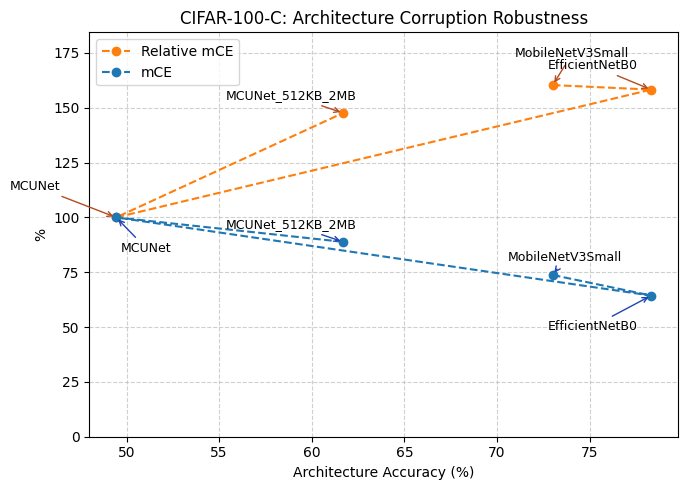

In [11]:
# ----- Gerar o gráfico de Architecture Corruption Robustness -----
fig, ax = plt.subplots(figsize=(7, 5))

# Plotando com marcadores
ax.plot(accuracy, relative_mce, 'o--', color='#ff7f0e', label='Relative mCE', markersize=6)
ax.plot(accuracy, mce, 'o--', color='#1f77b4', label='mCE', markersize=6)

# Adicionar anotações com setas para mCE (azul)
for i, name in enumerate(model_names):
    # Offset padrão - ajuste conforme necessário
    offset_mce = {
        "MCUNet": (40, -25),
        "MobileNetV3Small": (50, 10),
        "EfficientNetB0": (-10, -25),
    }
    ax.annotate(name, (accuracy[i], mce[i]), 
                textcoords="offset points", 
                xytext=offset_mce.get(name, (10, 10)), 
                ha='right', fontsize=9,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))

# Adicionar anotações para Relative mCE (laranja)
for i, name in enumerate(model_names):
    offset_rel = {
        "MCUNet": (-40, 20),
        "MobileNetV3Small": (55, 20),
        "EfficientNetB0": (-10, 15),
    }
    ax.annotate(name, (accuracy[i], relative_mce[i]), 
                textcoords="offset points", 
                xytext=offset_rel.get(name, (10, 10)), 
                ha='right', fontsize=9,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))

# Formatando o gráfico
ax.set_xlabel("Architecture Accuracy (%)")
ax.set_ylabel("%")
ax.set_title("CIFAR-100-C: Architecture Corruption Robustness")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Ajustar limites do eixo y
y_max = max(max(mce), max(relative_mce)) * 1.15
ax.set_ylim(0, y_max)

plt.tight_layout()

# Salvar como PDF
plt.savefig('cifar100c_architecture_corruption_robustness.pdf', format='pdf', bbox_inches='tight')
print("\nGráfico salvo em: cifar100c_architecture_corruption_robustness.pdf")

plt.show()

In [ ]:
# =============================================================================
# RECALCULAR CE/mCE COM BASELINE DIFERENTE (sem refazer inferências)
# =============================================================================
# Esta célula permite trocar o baseline e recalcular todas as métricas CE/mCE
# usando os dados de accuracy (acc_s1..acc_s5) já salvos no JSONL.
# NÃO é necessário rodar inferência novamente!

import json
import numpy as np
from pathlib import Path

# =====================
# CONFIGURAÇÃO: escolha o novo baseline aqui
# =====================
NOVO_BASELINE = "MCUNet"  # <-- MUDE AQUI para o modelo desejado
# Opções disponíveis (conforme seus modelos):
# - "MobileNetV3Small"
# - "EfficientNetB0"  
# - "MCUNet"

# =====================
# Carregar dados existentes
# =====================
RESULTS_DIR = Path("results")
SEVERITIES = [1, 2, 3, 4, 5]

# Encontrar o JSONL mais recente do CIFAR-100-C
jsonl_files = sorted(RESULTS_DIR.glob("cifar100c*_ce_results.jsonl"))
if not jsonl_files:
    raise FileNotFoundError("Nenhum arquivo JSONL encontrado em results/")

# Usar o primeiro encontrado (ou você pode especificar manualmente)
JSONL_PATH = jsonl_files[0]
print(f"Usando JSONL: {JSONL_PATH}")

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)

# Carregar todos os resultados
all_results = _load_jsonl(JSONL_PATH)

# Organizar por (modelo, corrupção) - pega o último se houver duplicatas
results_by_key = {}
for r in all_results:
    key = (r["model"], r["corruption"])
    results_by_key[key] = r

# Extrair modelos e corrupções únicos
model_names = sorted({r["model"] for r in all_results})
corruptions_list = sorted({r["corruption"] for r in all_results})

print(f"Modelos encontrados: {model_names}")
print(f"Corrupções: {len(corruptions_list)}")
print(f"Novo baseline: {NOVO_BASELINE}")

if NOVO_BASELINE not in model_names:
    raise ValueError(f"Baseline '{NOVO_BASELINE}' não encontrado! Opções: {model_names}")

# =====================
# Recalcular CE com novo baseline
# =====================
recalculated = []

for model in model_names:
    for corr in corruptions_list:
        key_model = (model, corr)
        key_baseline = (NOVO_BASELINE, corr)
        
        if key_model not in results_by_key or key_baseline not in results_by_key:
            continue
        
        r_model = results_by_key[key_model]
        r_baseline = results_by_key[key_baseline]
        
        # Recalcular CE por severidade e agregado
        num_err = 0.0
        den_err = 0.0
        ce_per_severity = {}
        
        for s in SEVERITIES:
            acc_model = r_model[f"acc_s{s}"]
            acc_baseline = r_baseline[f"acc_s{s}"]
            
            err_model = err_from_acc(acc_model)
            err_baseline = err_from_acc(acc_baseline)
            
            ce_s = err_model / err_baseline if err_baseline > 0 else float("nan")
            ce_per_severity[f"ce_s{s}"] = ce_s
            
            num_err += err_model
            den_err += err_baseline
        
        ce_mean = num_err / den_err if den_err > 0 else float("nan")
        
        recalculated.append({
            "model": model,
            "corruption": corr,
            "acc_mean_1_5": r_model["acc_mean_1_5"],
            "ce_mean_1_5": ce_mean,
            **ce_per_severity,
        })

# =====================
# Calcular mCE por modelo
# =====================
print(f"\n{'='*70}")
print(f"mCE RECALCULADO (baseline: {NOVO_BASELINE})")
print(f"{'='*70}")
print(f"{'Modelo':<20s} {'mCE (%)':<12s} {'Obs':<20s}")
print("-" * 50)

for model in model_names:
    rows = [r for r in recalculated if r["model"] == model]
    if not rows:
        continue
    mce = np.nanmean([r["ce_mean_1_5"] for r in rows]) * 100
    obs = "(baseline)" if model == NOVO_BASELINE else ""
    print(f"{model:<20s} {mce:<12.2f} {obs}")

# =====================
# Tabela CE% por corrupção
# =====================
print(f"\n{'='*70}")
print(f"CE (%) POR CORRUPÇÃO (baseline: {NOVO_BASELINE})")
print(f"{'='*70}")

colw = max(14, max(len(n) for n in model_names) + 2)
print(f"{'corruption':20s}" + "".join([f"{n:>{colw}s}" for n in model_names]))
print("-" * (20 + colw * len(model_names)))

for corr in corruptions_list:
    row_str = f"{corr:20s}"
    for model in model_names:
        rows = [r for r in recalculated if r["model"] == model and r["corruption"] == corr]
        if rows:
            ce_pct = rows[0]["ce_mean_1_5"] * 100
            row_str += f"{ce_pct:>{colw}.2f}"
        else:
            row_str += f"{'nan':>{colw}s}"
    print(row_str)

print(f"\n✓ CE/mCE recalculado com baseline '{NOVO_BASELINE}' (sem refazer inferências)")
print("  Para mudar o baseline, altere a variável NOVO_BASELINE e rode esta célula novamente.")

## Gerar novos arquivos JSON/JSONL com baseline = MCUNet_Official

Recalcula CE/mCE usando **MCUNet_Official** como baseline e salva:
- `cifar100c_baseline-MCUNet_Official_baseline_acc.json`  
- `cifar100c_baseline-MCUNet_Official_ce_results.jsonl`

In [2]:
# =============================================================================
# Gerar novos JSON/JSONL com baseline = MCUNet_Official
# Lê os dados de accuracy já existentes no JSONL (sem refazer inferências)
# =============================================================================
import json
import os
import numpy as np
from pathlib import Path

# ---- Configuração ----
NOVO_BASELINE = "MCUNet_Official"
SEVERITIES = [1, 2, 3, 4, 5]

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Arquivo de entrada (JSONL antigo com todas as accuracies)
JSONL_ANTIGO = RESULTS_DIR / "cifar100c_baseline-MCUNet_ce_results.jsonl"

# Arquivos de saída (novos, com baseline = MCUNet_Official)
RUN_TAG_NOVO = f"cifar100c_baseline-{NOVO_BASELINE}".replace(" ", "_")
BASELINE_ACC_PATH_NOVO = RESULTS_DIR / f"{RUN_TAG_NOVO}_baseline_acc.json"
CE_JSONL_PATH_NOVO     = RESULTS_DIR / f"{RUN_TAG_NOVO}_ce_results.jsonl"

def err_from_acc(acc: float) -> float:
    return 1.0 - float(acc)

# ---- Carregar JSONL antigo ----
def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

all_results = _load_jsonl(JSONL_ANTIGO)
print(f"Linhas lidas de {JSONL_ANTIGO.name}: {len(all_results)}")

# Desduplicar: pegar o último registro por (modelo, corrupção)
results_by_key = {}
for r in all_results:
    key = (r["model"], r["corruption"])
    results_by_key[key] = r

model_names = sorted({r["model"] for r in results_by_key.values()})
corruptions_list = sorted({r["corruption"] for r in results_by_key.values()})

print(f"Modelos: {model_names}")
print(f"Corrupções: {len(corruptions_list)}")

if NOVO_BASELINE not in model_names:
    raise ValueError(f"'{NOVO_BASELINE}' não encontrado no JSONL! Modelos disponíveis: {model_names}")

# ---- 1) Montar baseline_acc JSON (accuracies do MCUNet_Official por corrupção) ----
baseline_acc_novo = {}

for corr in corruptions_list:
    key = (NOVO_BASELINE, corr)
    if key not in results_by_key:
        print(f"  AVISO: {NOVO_BASELINE} não tem dados para '{corr}', pulando...")
        continue
    r = results_by_key[key]
    entry = {"corruption": corr}
    for s in SEVERITIES:
        entry[f"acc_s{s}"] = r[f"acc_s{s}"]
    entry["acc_mean_1_5"] = float(np.mean([r[f"acc_s{s}"] for s in SEVERITIES]))
    baseline_acc_novo[corr] = entry

# Salvar JSON do baseline
tmp = BASELINE_ACC_PATH_NOVO.with_suffix(".json.tmp")
tmp.write_text(json.dumps(baseline_acc_novo, ensure_ascii=False, indent=2), encoding="utf-8")
os.replace(tmp, BASELINE_ACC_PATH_NOVO)
print(f"\n✓ Baseline acc salvo em: {BASELINE_ACC_PATH_NOVO}")
print(f"  Corrupções no baseline: {len(baseline_acc_novo)}")

# ---- 2) Recalcular CE e salvar JSONL ----
# Limpa o arquivo de saída (cria do zero)
if CE_JSONL_PATH_NOVO.exists():
    # Backup antes de sobrescrever
    bak = CE_JSONL_PATH_NOVO.with_suffix(".jsonl.bak")
    CE_JSONL_PATH_NOVO.replace(bak)
    print(f"  Backup do JSONL anterior: {bak}")

with CE_JSONL_PATH_NOVO.open("w", encoding="utf-8") as f:
    for model in model_names:
        for corr in corruptions_list:
            key_model = (model, corr)
            if key_model not in results_by_key or corr not in baseline_acc_novo:
                continue

            r_model = results_by_key[key_model]
            r_base  = baseline_acc_novo[corr]

            row = {"model": model, "corruption": corr}
            num_err = 0.0
            den_err = 0.0

            for s in SEVERITIES:
                acc_ms = float(r_model[f"acc_s{s}"])
                acc_bs = float(r_base[f"acc_s{s}"])

                row[f"acc_s{s}"] = acc_ms
                ce_s = err_from_acc(acc_ms) / err_from_acc(acc_bs) if err_from_acc(acc_bs) > 0 else float("nan")
                row[f"ce_s{s}"] = ce_s

                num_err += err_from_acc(acc_ms)
                den_err += err_from_acc(acc_bs)

            row["acc_mean_1_5"] = float(np.mean([row[f"acc_s{s}"] for s in SEVERITIES]))
            row["ce_mean_of_ratios_1_5"] = float(np.nanmean([row[f"ce_s{s}"] for s in SEVERITIES]))
            row["ce_mean_1_5"] = float(num_err / den_err) if den_err > 0 else float("nan")

            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    f.flush()
    os.fsync(f.fileno())

print(f"✓ CE results salvo em: {CE_JSONL_PATH_NOVO}")

# ---- 3) Resumo mCE ----
ce_novo = _load_jsonl(CE_JSONL_PATH_NOVO)

print(f"\n{'='*70}")
print(f"mCE RECALCULADO — baseline: {NOVO_BASELINE}")
print(f"{'='*70}")
print(f"{'Modelo':<20s} {'mCE (%)':<12s} {'Obs'}")
print("-" * 55)

for model in model_names:
    rows = [r for r in ce_novo if r["model"] == model]
    if not rows:
        continue
    mce = np.nanmean([r["ce_mean_1_5"] for r in rows]) * 100
    obs = " ← baseline (≈100%)" if model == NOVO_BASELINE else ""
    print(f"{model:<20s} {mce:<12.2f}{obs}")

print(f"\n{'='*70}")
print(f"Arquivos gerados:")
print(f"  {BASELINE_ACC_PATH_NOVO}")
print(f"  {CE_JSONL_PATH_NOVO}")
print(f"{'='*70}")

Linhas lidas de cifar100c_baseline-MCUNet_ce_results.jsonl: 95
Modelos: ['EfficientNetB0', 'MCUNet', 'MCUNet_512KB_2MB', 'MCUNet_Official', 'MobileNetV3Small']
Corrupções: 19

✓ Baseline acc salvo em: results\cifar100c_baseline-MCUNet_Official_baseline_acc.json
  Corrupções no baseline: 19
✓ CE results salvo em: results\cifar100c_baseline-MCUNet_Official_ce_results.jsonl

mCE RECALCULADO — baseline: MCUNet_Official
Modelo               mCE (%)      Obs
-------------------------------------------------------
EfficientNetB0       66.33       
MCUNet               104.83      
MCUNet_512KB_2MB     92.38       
MCUNet_Official      100.00       ← baseline (≈100%)
MobileNetV3Small     76.32       

Arquivos gerados:
  results\cifar100c_baseline-MCUNet_Official_baseline_acc.json
  results\cifar100c_baseline-MCUNet_Official_ce_results.jsonl
